# Valutazione della robustezza adversarial di YOLO

Questo notebook valuta come variano le **detection di YOLO** al variare dell'intensita' della perturbazione adversarial (`epsilon`), confrontando gli attacchi **FGSM** e **PGD** (definiti in `adversarial.py`).

Per ogni valore di `epsilon` vengono calcolate, su piu' frame del video, le seguenti metriche:

- **Numero medio di detection** rimaste dopo l'attacco
- **Confidenza media** delle detection rimaste
- **Attack Success Rate (ASR)**: frazione media di oggetti "fatti scomparire" rispetto alla baseline (immagine originale)

I risultati vengono poi visualizzati in grafici al variare di `epsilon`, per FGSM e PGD.

## 2. Import

In [1]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

from adversarial import load_frame_as_tensor, fgsm_attack, pgd_attack, tensor_to_image

## 3. Parametri

- `SOURCE_VIDEO`: video da cui estrarre i frame di valutazione
- `MODEL_NAME`: modello YOLO pre-addestrato
- `CONF_THRESHOLD`: soglia di confidenza per le detection
- `FRAME_INDICES`: indici dei frame del video usati per la valutazione (piu' frame = stima piu' robusta ma piu' lenta)
- `EPSILON_VALUES`: valori di epsilon da testare
- `ALPHA`, `NUM_ITER`: parametri di PGD (step size e numero di iterazioni)

In [ ]:
BASE_DIR = Path.cwd().parent

SOURCE_VIDEO = BASE_DIR / "DATA" / "render" / "splacto_living_room.mp4"
#MODEL_NAME = "yolo11n.pt"
MODEL_NAME = "yolov8n.pt"
CONF_THRESHOLD = 0.20

# Frame del video usati per la valutazione (indici)
FRAME_INDICES = [0, 30, 60, 90, 120]

# Valori di epsilon da testare (0 = nessuna perturbazione, baseline)
EPSILON_VALUES = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1]

# Parametri PGD
ALPHA = 0.005
NUM_ITER = 10

## 4. Caricamento del modello pre-addestrato

In [3]:
model = YOLO(MODEL_NAME)
print("Modello caricato:", MODEL_NAME)

Modello caricato: yolo11n.pt


## 5. Funzioni di supporto

- `get_detections`: esegue l'inferenza su un'immagine e restituisce numero di detection e confidenze.
- `load_eval_frames`: estrae i frame di valutazione dal video come tensori (per gli attacchi) e immagini numpy (per l'inferenza).
- `evaluate_epsilon`: applica FGSM o PGD a un dato `epsilon` su tutti i frame e calcola le metriche aggregate.

In [4]:
def get_detections(model, img, conf_threshold):
    """Esegue l'inferenza e restituisce (numero detection, array di confidenze)."""
    results = model(img, conf=conf_threshold, verbose=False)
    boxes = results[0].boxes
    n = len(boxes)
    confs = boxes.conf.cpu().numpy() if n > 0 else np.array([])
    return n, confs

In [5]:
def load_eval_frames(video_path, frame_indices, imgsz=640, device="cpu"):
    """Carica piu' frame del video come tensori (per gli attacchi)."""
    frames = []
    for idx in frame_indices:
        tensor, _ = load_frame_as_tensor(video_path, frame_index=idx, imgsz=imgsz, device=device)
        frames.append(tensor.detach())
    return frames


eval_frames = load_eval_frames(SOURCE_VIDEO, FRAME_INDICES)
print(f"Caricati {len(eval_frames)} frame per la valutazione.")

Caricati 5 frame per la valutazione.


## 6. Baseline (epsilon = 0)

Calcola le detection sui frame originali, senza alcuna perturbazione. Questi valori sono il riferimento (100%) per il calcolo dell'Attack Success Rate.

In [6]:
baseline_counts = []
baseline_confs = []

for tensor in eval_frames:
    img = tensor_to_image(tensor)
    n, confs = get_detections(model, img, CONF_THRESHOLD)
    baseline_counts.append(n)
    baseline_confs.append(confs)

for i, (n, confs) in enumerate(zip(baseline_counts, baseline_confs)):
    mean_c = confs.mean() if len(confs) > 0 else 0.0
    print(f"Frame {FRAME_INDICES[i]:>4}: {n} detection, confidenza media = {mean_c:.3f}")

Frame    0: 7 detection, confidenza media = 0.557
Frame   30: 8 detection, confidenza media = 0.555
Frame   60: 8 detection, confidenza media = 0.508
Frame   90: 5 detection, confidenza media = 0.610
Frame  120: 8 detection, confidenza media = 0.481


## 7. Funzione di valutazione per un dato epsilon

Per ogni frame applica l'attacco scelto (`fgsm` o `pgd`), esegue l'inferenza sull'immagine perturbata e calcola:

- numero di detection rimaste
- confidenza media delle detection rimaste
- success rate = `max(0, baseline_n - adv_n) / baseline_n` (0 se la baseline non aveva detection)

I valori vengono poi mediati su tutti i frame.

In [7]:
def evaluate_epsilon(model, frames, baseline_counts, epsilon, conf_threshold,
                      method="fgsm", alpha=ALPHA, num_iter=NUM_ITER):
    """Valuta le metriche di robustezza per un dato epsilon e metodo di attacco.

    Args:
        method: "fgsm" o "pgd". Se epsilon == 0, non viene applicato alcun attacco.

    Returns:
        dict con le metriche medie su tutti i frame: n_detections, mean_confidence, asr.
    """
    n_detections_list = []
    mean_conf_list = []
    asr_list = []

    for tensor, base_n in zip(frames, baseline_counts):
        if epsilon == 0:
            adv_img = tensor_to_image(tensor)
        else:
            input_tensor = tensor.clone().detach().requires_grad_(True)
            if method == "fgsm":
                adv_tensor, _ = fgsm_attack(model, input_tensor, epsilon=epsilon)
            elif method == "pgd":
                adv_tensor, _ = pgd_attack(model, input_tensor, epsilon=epsilon, alpha=alpha, num_iter=num_iter)
            else:
                raise ValueError(f"Metodo non valido: {method}")
            adv_img = tensor_to_image(adv_tensor)

        n, confs = get_detections(model, adv_img, conf_threshold)

        n_detections_list.append(n)
        mean_conf_list.append(confs.mean() if len(confs) > 0 else 0.0)

        if base_n > 0:
            asr_list.append(max(0, base_n - n) / base_n)
        else:
            asr_list.append(0.0)

    return {
        "n_detections": float(np.mean(n_detections_list)),
        "mean_confidence": float(np.mean(mean_conf_list)),
        "asr": float(np.mean(asr_list)),
    }

## 8. Sweep su epsilon

Esegue `evaluate_epsilon` per ogni valore di `epsilon` in `EPSILON_VALUES`, per entrambi i metodi (FGSM e PGD), e raccoglie i risultati in un DataFrame.

In [8]:
records = []

for epsilon in EPSILON_VALUES:
    # FGSM (per epsilon=0 il risultato e' la baseline, identico per entrambi i metodi)
    res_fgsm = evaluate_epsilon(model, eval_frames, baseline_counts, epsilon, CONF_THRESHOLD, method="fgsm")
    records.append({"epsilon": epsilon, "method": "FGSM", **res_fgsm})
    print(f"epsilon={epsilon:<6} FGSM -> detections={res_fgsm['n_detections']:.2f}, "
          f"conf={res_fgsm['mean_confidence']:.3f}, ASR={res_fgsm['asr']:.2f}")

    if epsilon == 0:
        # epsilon=0 -> nessun attacco, stesso risultato per PGD
        res_pgd = res_fgsm
    else:
        res_pgd = evaluate_epsilon(model, eval_frames, baseline_counts, epsilon, CONF_THRESHOLD, method="pgd")
    records.append({"epsilon": epsilon, "method": "PGD", **res_pgd})
    print(f"epsilon={epsilon:<6} PGD  -> detections={res_pgd['n_detections']:.2f}, "
          f"conf={res_pgd['mean_confidence']:.3f}, ASR={res_pgd['asr']:.2f}")

df_results = pd.DataFrame(records)
df_results

epsilon=0.0    FGSM -> detections=7.20, conf=0.542, ASR=0.00
epsilon=0.0    PGD  -> detections=7.20, conf=0.542, ASR=0.00
epsilon=0.005  FGSM -> detections=4.20, conf=0.474, ASR=0.39
epsilon=0.005  PGD  -> detections=1.40, conf=0.448, ASR=0.78
epsilon=0.01   FGSM -> detections=4.40, conf=0.448, ASR=0.39
epsilon=0.01   PGD  -> detections=0.20, conf=0.090, ASR=0.97
epsilon=0.02   FGSM -> detections=4.40, conf=0.439, ASR=0.38
epsilon=0.02   PGD  -> detections=0.00, conf=0.000, ASR=1.00
epsilon=0.03   FGSM -> detections=4.80, conf=0.444, ASR=0.33
epsilon=0.03   PGD  -> detections=0.00, conf=0.000, ASR=1.00
epsilon=0.05   FGSM -> detections=4.00, conf=0.411, ASR=0.43
epsilon=0.05   PGD  -> detections=0.00, conf=0.000, ASR=1.00
epsilon=0.08   FGSM -> detections=1.60, conf=0.209, ASR=0.76
epsilon=0.08   PGD  -> detections=0.00, conf=0.000, ASR=1.00
epsilon=0.1    FGSM -> detections=0.20, conf=0.048, ASR=0.97
epsilon=0.1    PGD  -> detections=0.00, conf=0.000, ASR=1.00


,epsilon,method,n_detections,mean_confidence,asr
0,0.000,FGSM,7.2,0.542235,0.000000
1,0.000,PGD,7.2,0.542235,0.000000
2,0.005,FGSM,4.2,0.474436,0.389286
3,0.005,PGD,1.4,0.448401,0.776429
4,0.010,FGSM,4.4,0.448218,0.394286
5,0.010,PGD,0.2,0.090407,0.971429
6,0.020,FGSM,4.4,0.438683,0.375714
7,0.020,PGD,0.0,0.000000,1.000000
8,0.030,FGSM,4.8,0.444019,0.325714
9,0.030,PGD,0.0,0.000000,1.000000


## 9. Grafici

I grafici seguenti mostrano l'andamento delle metriche al variare di `epsilon`, confrontando FGSM e PGD.

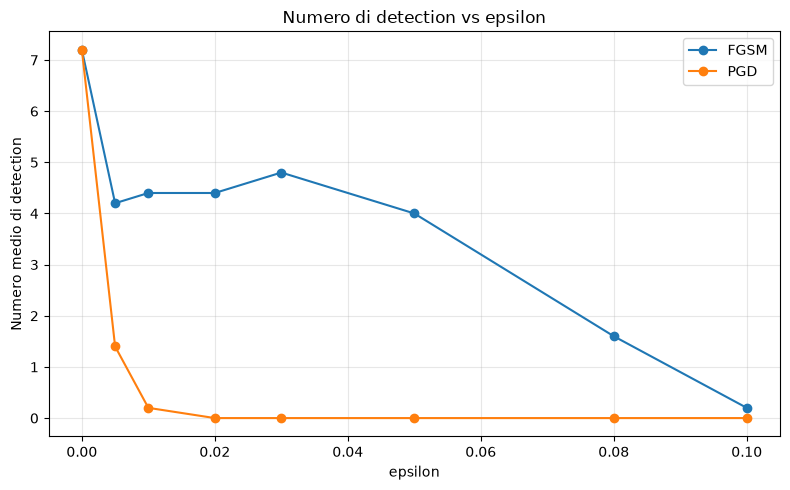

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for method, group in df_results.groupby("method"):
    ax.plot(group["epsilon"], group["n_detections"], marker="o", label=method)

ax.set_xlabel("epsilon")
ax.set_ylabel("Numero medio di detection")
ax.set_title("Numero di detection vs epsilon")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

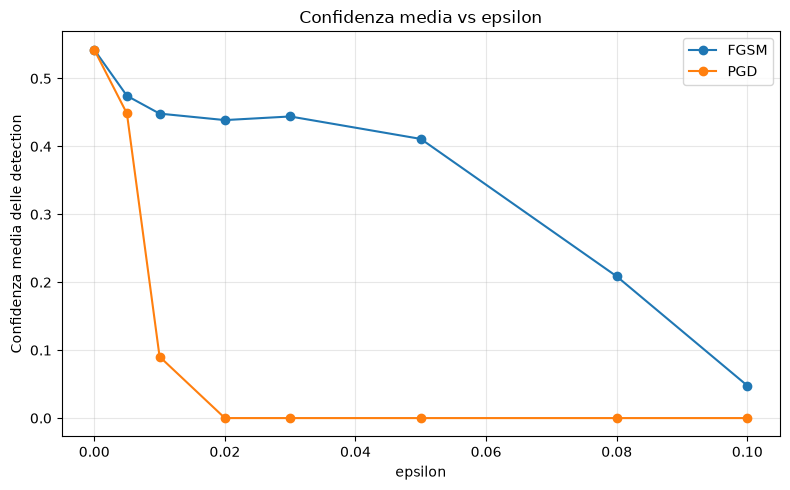

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for method, group in df_results.groupby("method"):
    ax.plot(group["epsilon"], group["mean_confidence"], marker="o", label=method)

ax.set_xlabel("epsilon")
ax.set_ylabel("Confidenza media delle detection")
ax.set_title("Confidenza media vs epsilon")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

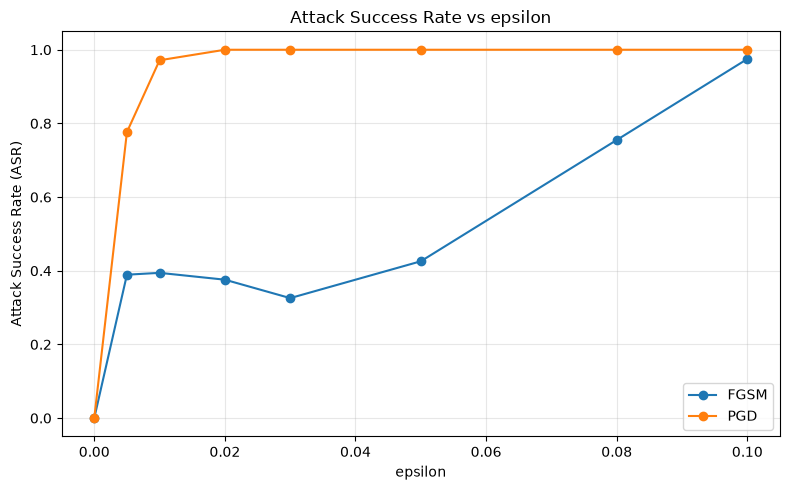

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for method, group in df_results.groupby("method"):
    ax.plot(group["epsilon"], group["asr"], marker="o", label=method)

ax.set_xlabel("epsilon")
ax.set_ylabel("Attack Success Rate (ASR)")
ax.set_title("Attack Success Rate vs epsilon")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Note

- **ASR (Attack Success Rate)** = frazione di detection della baseline che "scompaiono" (vanno sotto la soglia di confidenza) dopo l'attacco. ASR=1 significa che tutte le detection originali sono state nascoste.
- Ci si aspetta che **PGD raggiunga un ASR piu' alto di FGSM a parita' di `epsilon`**, dato che esplora la perdita in modo piu' accurato su piu' iterazioni.
- All'aumentare di `epsilon`, anche la **perturbazione diventa piu' visibile** nell'immagine: questi grafici aiutano a scegliere un compromesso tra efficacia dell'attacco e impercettibilita'.
- Aumentare `FRAME_INDICES` (piu' frame) rende le metriche piu' stabili ma aumenta il tempo di calcolo, soprattutto per PGD.